# Project 08 — Molecule Search Engine (Substructure Search)

This project focuses on building a **Molecule Search Engine** using Substructure Searching in RDKit. Substructure search is a core functionality in Cheminformatics that allows us to find all molecules in a dataset that contain a specific molecular scaffold or functional group.

---

## Project Objective

1. **Load a Dataset**: Read a dataset of molecules.
2. **Define a Query**: Use SMARTS (SMILES Arbitrary Target Specification) to define a substructure pattern.
3. **Search the Database**: Filter molecules that contain the specified substructure.
4. **Visualize Results**: Highlight the matched substructure in the result molecules.

---


## 1. Import Required Libraries

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

---
## 2. Load the Dataset
We will use our local dataset containing a list of SMILES strings.

In [2]:
# Define the dataset path
dataset_path = "../../dataset/molecules_100.csv"

# Read the dataset using Pandas
df = pd.read_csv(dataset_path)

display(df.head())

,Name,SMILES
0,Water,O
1,Methane,C
2,Ethane,CC
3,Propane,CCC
4,Butane,CCCC


---
## 3. Convert SMILES to RDKit Molecules
We need to convert the text-based SMILES strings into molecular objects that RDKit can understand and analyze.

In [3]:
# Create a new column with RDKit molecule objects
df["Mol"] = df["SMILES"].apply(Chem.MolFromSmiles)

# Remove any rows where molecule conversion failed (Invalid SMILES)
df = df.dropna(subset=["Mol"])

print(f"Total valid molecules: {len(df)}")

Total valid molecules: 100


---
## 4. Define the Substructure Query (SMARTS)

SMARTS is a language that allows you to specify substructures using rules. 
For example:
* `c1ccccc1` : Benzene ring
* `C(=O)O` : Carboxylic acid group
* `c1ccncc1` : Pyridine ring

Query Substructure:


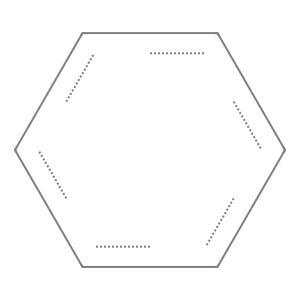

In [4]:
# Let's search for molecules containing a Benzene ring
query_smarts = "c1ccccc1"  

# Convert the SMARTS string to an RDKit query molecule
query_mol = Chem.MolFromSmarts(query_smarts)

print("Query Substructure:")
display(Draw.MolToImage(query_mol))

---
## 5. Perform the Substructure Search
We will iterate through our dataset and check if each molecule contains the query substructure using the `HasSubstructMatch()` function.

In [5]:
def search_substructure(mol, query):
    """
    Checks if the molecule contains the given substructure query.
    """
    if mol is None:
        return False
    return mol.HasSubstructMatch(query)

# Apply the search function to the dataset
df["Match"] = df["Mol"].apply(lambda x: search_substructure(x, query_mol))

# Filter the dataset to keep only the matched molecules
matched_df = df[df["Match"] == True].reset_index(drop=True)

print(f"Found {len(matched_df)} molecules containing the query substructure.")
display(matched_df[["Name", "SMILES"]].head())

Found 18 molecules containing the query substructure.


,Name,SMILES
0,Benzoic Acid,C1=CC=C(C=C1)C(=O)O
1,Phenol,Oc1ccccc1
2,Benzyl Alcohol,OCc1ccccc1
3,Benzene,c1ccccc1
4,Toluene,Cc1ccccc1


---
## 6. Visualize the Search Results
To make our search engine visually appealing, we will highlight the matched substructure atoms in the resulting molecules.

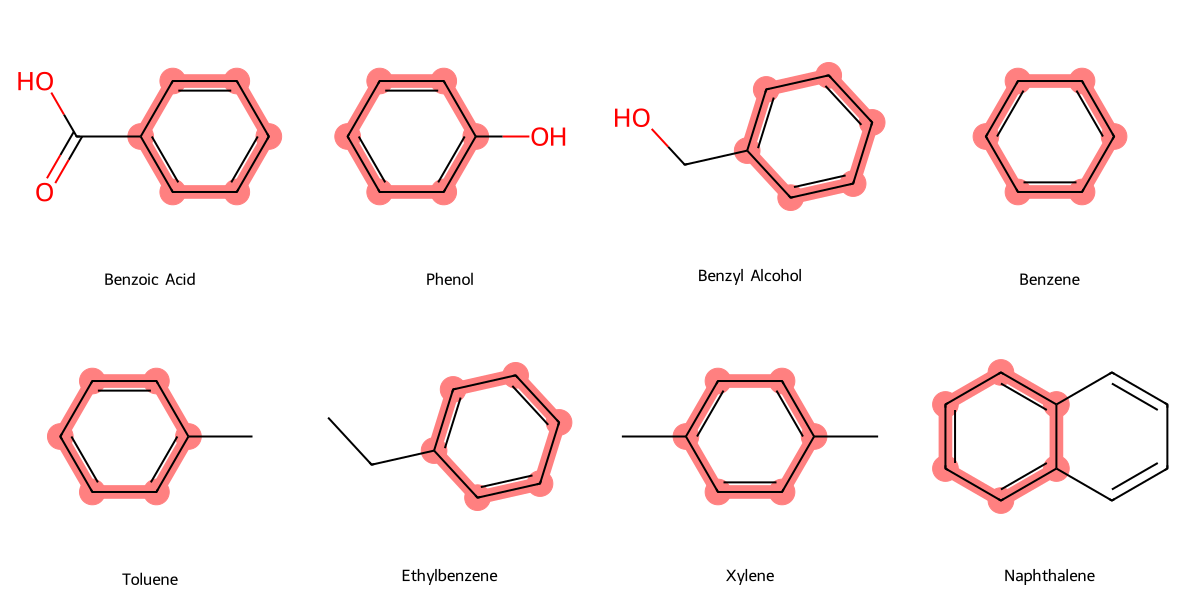

In [6]:
# Extract the matched molecules and their names
result_mols = matched_df["Mol"].tolist()
result_names = matched_df["Name"].tolist()

# Get the exact atom indices to highlight for each molecule
highlight_lists = [mol.GetSubstructMatch(query_mol) for mol in result_mols]

# Visualize the first 8 matches in a grid
img = Draw.MolsToGridImage(
    result_mols[:8], 
    molsPerRow=4, 
    subImgSize=(300, 300), 
    legends=result_names[:8],
    highlightAtomLists=highlight_lists[:8]
)

display(img)

---
## Summary

In this project, we successfully built a basic **Molecule Search Engine**. 
We learned how to:
1. Define a substructure pattern using **SMARTS**.
2. Use `HasSubstructMatch()` to filter a molecular dataset.
3. Use `GetSubstructMatch()` to find exactly which atoms map to the query.
4. Visualize and **highlight** the targeted substructure inside complex molecules.

This technique is heavily used in **Lead Optimization** and **Scaffold Hopping** to find similar drugs with the same core chemical backbone.